# Decision Tree Classification

This notebook demonstrates the use of a **Decision Tree classifier** for a supervised binary classification task. The goal is to predict whether an individual's income exceeds \$50K per year using demographic and employment-related features from the U.S. Census dataset.

Decision Trees are nonlinear, rule-based models that recursively partition the feature space to maximize class separation. They are highly interpretable but prone to overfitting if not properly regularized.


**Goal** <br>

The goal of this notebook is to train and evaluate a Decision Tree classifier to predict whether an individual earns more than 50K per year using demographic and employment related features from the U.S. Census Adult Income dataset.

**Repository structure** <br>

This notebook uses modular utilities defined in the project repository
Data loading and preprocessing logic is implemented in the src module
Model training and evaluation are performed through reusable helper functions
This separation keeps notebooks focused on analysis and interpretation

In [1]:
import os
import sys
import importlib

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", "..", ".."))
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

import rice_ml.supervised_learning.decision_tree as dt
dt = importlib.reload(dt)  # force reload from disk

print("Using decision_tree module at:", dt.__file__)
print("Available names:", [n for n in dir(dt) if "decision" in n or "load_" in n or "prepare" in n or "evaluate" in n])

Using decision_tree module at: C:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\src\rice_ml\supervised_learning\decision_tree.py
Available names: ['evaluate_classifier', 'load_census_dataset', 'prepare_train_test', 'train_decision_tree_classifier']


In [2]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)


## Dataset

We use a processed version of the U.S. Census Income dataset, commonly known as the *Adult Income* dataset.

**Target variable**
- `<=50K` vs `>50K` annual income (binary classification)

**Features**
- Numerical: age, education level, capital gain/loss, hours worked per week
- Categorical (one-hot encoded): occupation, marital status, relationship, sex, workclass, native country, and others

The dataset is already cleaned and encoded by the custom data-loading utility used in this project.




In [3]:
X, y = dt.load_census_dataset()

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

X.head()


Shape of X: (48842, 99)
Shape of y: (48842,)


,age,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,13,2174,0,40,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


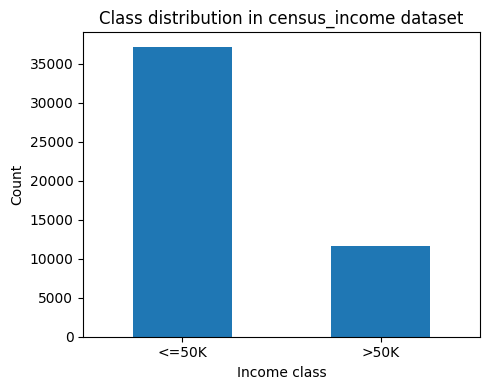

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["<=50K", ">50K"], rotation=0)
plt.xlabel("Income class")
plt.ylabel("Count")
plt.title("Class distribution in census_income dataset")
plt.tight_layout()
plt.show()


### Class Imbalance

The target variable is moderately imbalanced, with a larger proportion of individuals earning `<=50K` per year. This imbalance motivates the use of evaluation metrics beyond accuracy, such as precision, recall, and F1-score.


In [5]:
X_train, X_test, y_train, y_test = dt.prepare_train_test(X, y, test_size=0.25)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 36631
Test size: 12211


## Model Training

We train a Decision Tree classifier with regularization to control model complexity.

Key hyperparameters:
- `max_depth`: limits the depth of the tree to prevent overfitting
- `min_samples_split`: enforces a minimum number of samples required to split a node
- `min_samples_leaf`: ensures that leaf nodes contain enough samples for stability


In [6]:
tree_clf = dt.train_decision_tree_classifier(
    X_train,
    y_train,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
)

acc, cm, report, y_pred = dt.evaluate_classifier(tree_clf, X_test, y_test)

print("Test accuracy:", acc)
print("\nClassification report:\n")
print(report)


Test accuracy: 0.8566047006797151

Classification report:

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      9289
           1       0.78      0.56      0.65      2922

    accuracy                           0.86     12211
   macro avg       0.83      0.75      0.78     12211
weighted avg       0.85      0.86      0.85     12211



## Model Performance

The Decision Tree achieves strong overall accuracy while exhibiting different performance characteristics across income classes.

Key observations:
- The model performs very well on the majority class (`<=50K`)
- Recall for the `>50K` class is lower, reflecting the class imbalance and the difficulty of identifying high-income individuals
- Precision–recall tradeoffs suggest that further tuning or ensemble methods may improve minority-class performance
- From a decision making perspective, misclassifying high income individuals may be more costly in some applications, motivating alternative thresholds


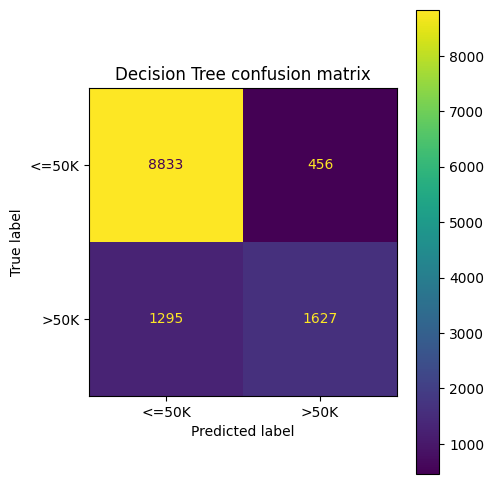

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"],
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Decision Tree confusion matrix")
plt.tight_layout()
plt.show()


## Effect of Tree Depth on Model Performance

Decision Trees are prone to overfitting as depth increases. Shallow trees may underfit, while deeper trees can memorize training data and generalize poorly.

To illustrate this tradeoff, we evaluate model performance across different values of `max_depth`.


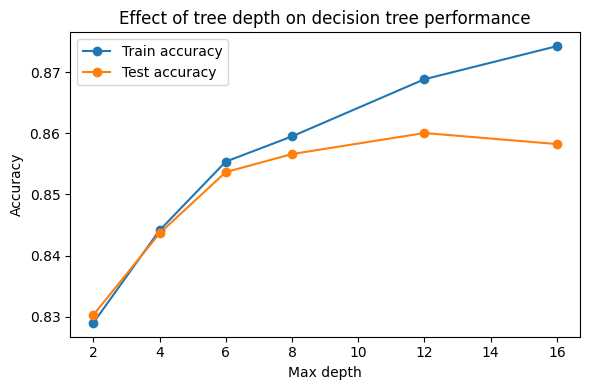

In [8]:
depths = [2, 4, 6, 8, 12, 16]
train_acc = []
test_acc = []

for d in depths:
    model = dt.train_decision_tree_classifier(
        X_train,
        y_train,
        max_depth=d,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
    )

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(6, 4))
plt.plot(depths, train_acc, marker="o", label="Train accuracy")
plt.plot(depths, test_acc, marker="o", label="Test accuracy")
plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.title("Effect of tree depth on decision tree performance")
plt.legend()
plt.tight_layout()
plt.show()


As tree depth increases, training accuracy monotonically improves, while test accuracy initially increases and then plateaus or slightly degrades.

This divergence illustrates classic overfitting behavior:
- shallow trees underfit due to limited expressive power,
- deeper trees increasingly overfit by memorizing training data rather than learning generalizable patterns.

An intermediate tree depth therefore provides the best balance between bias and variance, motivating the chosen hyperparameter setting for the final model.


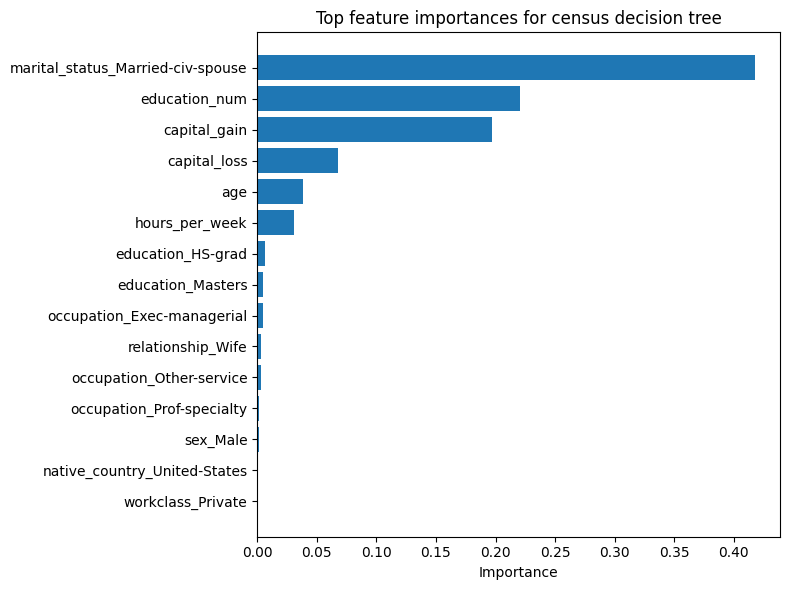

In [9]:
importances = tree_clf.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 15
top_indices = indices[:top_k]

plt.figure(figsize=(8, 6))
plt.barh(
    range(len(top_indices)),
    importances[top_indices][::-1],
)
plt.yticks(
    range(len(top_indices)),
    X_train.columns[top_indices][::-1],
)
plt.xlabel("Importance")
plt.title("Top feature importances for census decision tree")
plt.tight_layout()
plt.show()


## Feature Importance Analysis

Decision Trees provide intrinsic feature importance scores based on how frequently and how effectively each feature is used to reduce impurity.

Key insights:
- Marital status and education-related variables are among the strongest predictors
- Capital gain and hours worked per week also contribute significantly
- Feature importance should be interpreted cautiously, as correlated features may share importance


## Conclusion

This example illustrates how Decision Trees can model complex, nonlinear relationships in tabular data while remaining interpretable.

Key takeaways:
- Decision Trees handle mixed feature types naturally
- Regularization is essential to prevent overfitting
- While interpretability is a strength, single trees can be unstable

These limitations motivate the use of ensemble methods such as Random Forests and Gradient Boosting, which are explored in later sections of this project.
